# Walmart Inc.


#### By: Karan Agarwal

## Section 1: Problem Statment and Scope

### 1.1 Problem Statement

The objective of this project is:

⟫⟫ To analyze the data of the customers who purchased products from the Walmart Store during Black Friday Sale.

⟫⟫ To track the amount spent by the customers per transaction.

⟫⟫ To divide the whole customer base on various categories available such as Gender, Marital status, Age etc., and calculate average spending accordingly.

⟫⟫ To use the Central Limit Theorem to compute the various confidence intervals such as 90%, 95% and 99%.

⟫⟫ To change the sample size to observe the distribution of the mean of the expenses by various categories available.

⟫⟫ To conclude the results and check if the confidence intervals of various categories available spends are overlapping or not.

*The objective is to support data-driven decision-making related to customer segmentation and spending behavior during high-impact sales events.*

### 1.2 Business Objectives

The key business questions this project aims to answer are:

⟫⟫ Are women spending more money per transaction than men? Why or Why not?

⟫⟫ What are the confidence intervals and distribution of the mean of the expenses by female and male customers?

⟫⟫ Are confidence intervals of average male and female spending overlapping? How can Walmart leverage this conclusion to make changes or improvements?

⟫⟫ What are the results when the same activity is performed for Married vs Unmarried?

⟫⟫ What are the results when the same activity is performed for different age categories?
ts)

### 1.3 Scope of the Analysis

✔ Exploratory Data Analysis (EDA)

✔ Data cleaning and preprocessing

✔ Univariate and bivariate anal

✔ Identification of trends and correlations

✔ Usage of Central Limit Theorem to calculate Confidence Interval

✔ Business Oriented insights and recommendations.

### 1.4 Key Deliverables

↠ Cleaned and well documented dataset.

↠ Insightful Visualizations.

↠ Clear business interpretations.

↠ Actionable recommendations.ions

## Section 2: Data Understanding and Basic Metrics

### 2.1 Importing all the required Libraries

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Making Matplotlib plots directly visible in the notebook
%matplotlib inline

# Setting Seborn's default plotting style to "whitegrid" for white background and grid lines
sns.set_style("whitegrid")

# Setting Matplotlib's default figure size to 11 * 6 ( width 11 inches and height 6 inches ) for better aspect ratio
plt.rcParams['figure.figsize'] = (11, 6)

### 2.2 Loading the Dataset and Displaying top 5 rows

In [57]:
# Loading the dataset
df = pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\walmart_data.txt")

# Displaying top 5 rows
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


### 2.3 Shape of the dataset

In [59]:
df.shape

(550068, 10)

#### Interpretation:
The dataset contains 550068 rows and 10 attributes (columns).

Each row represents a unique combination of a customer(User_ID) and their transactions(Product purchasesd).

A sample size of approx 550K transactions is large enough to perform meaningful statistical analysis and uncover trends with good reliability.

### 2.4 Datatypes and General Information

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


#### Interpretation:
The dataset consist of 10 columns, of which 5 are of categorical and the other 5 are of numerical in nature.

The dataset has no missing values ( All 550068 entries are present in all the 10 columns). The absence of missing values suggests that the dataset is pre-cleaned and likely curated for data analysis.

The dataset occupies minimal memory, indicating efficient storage and suitability for in-memory analysis.

### 2.5 Column Names

In [65]:
df.columns.tolist()

['User_ID',
 'Product_ID',
 'Gender',
 'Age',
 'Occupation',
 'City_Category',
 'Stay_In_Current_City_Years',
 'Marital_Status',
 'Product_Category',
 'Purchase']

#### Interpretation:
The dataset contains the following columns: ['User_ID',
 'Product_ID',
 'Gender',
 'Age',
 'Occupation',
 'City_Category',
 'Stay_In_Current_City_Years',
 'Marital_Status',
 'Product_Category',
 'Purchase']

### 2.6 Missing Values Detection

In [68]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

#### Interpretation:
No missing values were found. Therefore, we can proceed directly to exploratory analysis without imputation steps.

### 2.7 Value Counts Category Wise

In [71]:
Categorical_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Occupation', 'Product_Category']

for col in Categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())


Value Counts for Gender:
Gender
M    414259
F    135809
Name: count, dtype: int64

Value Counts for Age:
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64

Value Counts for City_Category:
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64

Value Counts for Stay_In_Current_City_Years:
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64

Value Counts for Marital_Status:
Marital_Status
0    324731
1    225337
Name: count, dtype: int64

Value Counts for Occupation:
Occupation
4     72308
0     69638
7     59133
1     47426
17    40043
20    33562
12    31179
14    27309
2     26588
16    25371
6     20355
3     17650
10    12930
5     12177
15    12165
11    11586
19     8461
13     7728
18     6622
9      6291
8      1546
Name: count, dtype: int64

Value Counts for Product_Category:
Product_Category
5     15

#### Interpretation:
##### Gender:
The gender distribution is highly biased towards the male with a majority of 414259 males in contrast to 135809 females. This shows, that the majority of the customers are male only. 

##### Age:
All the customers are being divided into 7 age categories. The majority of the customers fall into three buckets; 26-35, 36-45 and 18-25. Whereas, 0-17 bucket contains the lowest number of customers.

##### City Category:
There are three city categories are being available within the dataset. With 231173 customers, the 'B' category dominates the customer-base, which is being followed by category 'C' and 'A' respectively.

##### Years of stay in the current city:
A customer's years of stay in the current city is being divided into 5 categories. 1 year dominates the dataset with approximately 190K customers whereas the rest of the customers are almost equally divided into other 4 categories i.e. 0 years, 2 years, 3 years and 4+ years.

##### Marital Status:
There are approximately 325K non-married customers present in the dataset against the 225K married customers. 

##### Occupation:
The occupation of the customers are being divided into 21 categories. Among them, categories 4, 0 and 7 dominates the customer base, whereas 1, 17, 20 and 12 also have a significant number of customers. This show the diversity of the customers present in the dataset.

##### Product Category:
All the products are being divided into 20 major categories. Among them, categories 5, 1 and 8 has the most numbers of products allocated to them. 

## Section 3: Data Cleaning and Datatype Conversion

### 3.1 Duplicated Rows

In [75]:
df.duplicated().sum()

0

#### Interpretation:
No duplicate rows were found. Therefore, no deduplication is required.

### 3.2 Unique Values in each column

In [78]:
df.nunique().sort_values(ascending = False)

Purchase                      18105
User_ID                        5891
Product_ID                     3631
Occupation                       21
Product_Category                 20
Age                               7
Stay_In_Current_City_Years        5
City_Category                     3
Gender                            2
Marital_Status                    2
dtype: int64

#### Interpretation:
##### Purchase:
The purchase column represents the 18105 unique transaction amount, which will be useful for numerical calculations.

##### Identifiers:
Both the User_ID and Product_ID columns serve as the identifier within the dataset. There are 5891 unique values in the User_ID, which represents 5891 unique customers, similarly, there are 3631 unique values in the product_id column, which represents 3631 unique products.

##### Major categories:
The occupation column contains 21 unique values, which represents 21 different occupations.
The Product_category column contains 20 unique values, which represents 20 unique product categories. 
The Age column contains 7 unique values, which represents 7 different age categories. 
the Stay_In_Current_City_Years contains 5 unique values, which represents 5 different years category.

##### Minor categories:
The City column has 3 unique values, which represents 3 different city categories.
The Gender and marital_status have 2 unique values each, which represents male/female and single/married categories respectively.

### 3.3 Columns' type conversion

In [81]:
columns_to_convert = ['User_ID', 'Occupation', 'Marital_Status', 'Product_Category']

for column in columns_to_convert:
    df[column] = df[column].astype(str)

# Rechecking the changes made
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  object
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 42.0+ MB


#### Intuition behind the same:
Although the dataset contains 5 categorical and 5 numerical columns, but majority of numerical columns are categorical in nature, such as User_ID, Occupation, Marital_Status, and Product_Category. It does not make sense to perform statistical operations on a categorical column.

In the dataset, only the purchase column is being identified as a numerical column, which will be used extensively for performing statistical operations.

## Section 4: Statistical Summary and Outlier Detection

### 4.1 Statistical Summary for Numerical Columns

In [85]:
df['Purchase'].describe().round(2)

count    550068.00
mean       9263.97
std        5023.07
min          12.00
25%        5823.00
50%        8047.00
75%       12054.00
max       23961.00
Name: Purchase, dtype: float64

#### Interpretation:
The statistical summary is provided for the 'Purchase' column, which is the only numerical column available in the dataset. 

The relatively large **standard deviation** compared to the mean highlights high variability in customer spending, which supports the need for CLT-based inference rather than assuming normality.

The purchase amount is found to be as low as 12 and as high as 23961, indicating **extreme outliers** present in the dataset.

The mean(9264) is higher than the **median**(8047), indicating a **right-skewed distribution**. Further, we can interpret that most customers spend close to 8047, but the presence of high-value purchasers pushed the average transaction value to 9264, which is common in retail data. 

### 4.2 Outlier Detection

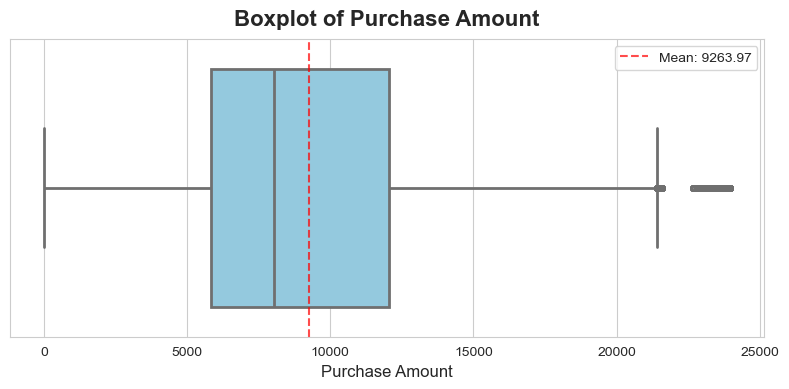

In [88]:
plt.figure(figsize=(8, 4))
ax = sns.boxplot(x=df['Purchase'], 
                 color='skyblue',
                 linewidth=2,
                 fliersize=4)

# Adding mean marker
mean_val = df['Purchase'].mean()
plt.axvline(x=mean_val, color='red', linestyle='--', alpha=0.7, 
            label=f'Mean: {mean_val:.2f}')

# Adding labels and statistics
plt.title("Boxplot of Purchase Amount", fontsize=16, fontweight='bold', pad=10)
plt.xlabel("Purchase Amount", fontsize=12)
plt.legend()

plt.tight_layout()

#### Interpretation:
The above boxplot confirms the statistical summary provided in the earlier stage.

It confirms that there are high-value transactions present in the upper tail, pushing mean towards them and it is also observed that very few low-value transactions are present compared to the upper tail.

Although high-value outliers are present, they are not treated or removed since they represent genuine customer transactions, which are crucial for business insights and revenue analysis. Removing them would distort the true spending behavior during Black Friday.

## Section 5: Univariate analysis

### 5.1 Distribution of Purchase amount

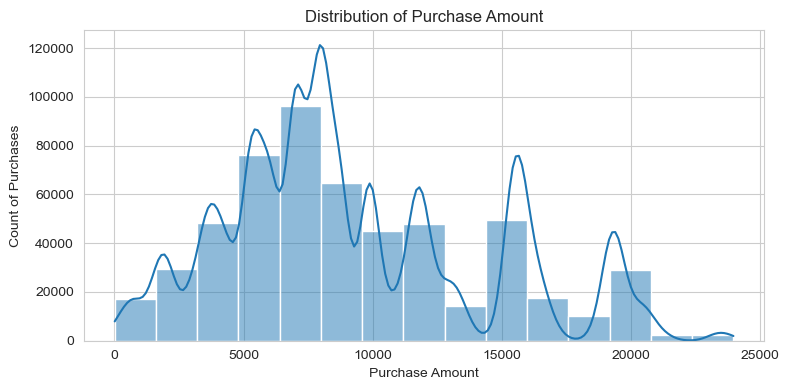

In [92]:
plt.figure(figsize= (8,4))

sns.histplot(df['Purchase'], kde= True, bins= 15)
plt.title("Distribution of Purchase Amount")
plt.xlabel('Purchase Amount')
plt.ylabel('Count of Purchases')


plt.tight_layout()
plt.show()

#### Interpretation:
The distribution of purchase amount is right-skewed and non-normal, which is consistent with typical retail transaction data. The histogram shows multiple peaks rather than a smooth bell-shaped curve, indicating that purchases tend to occur at specific price ranges rather than being uniformly distributed.

The long right tail confirms the presence of high-value transactions, which aligns with the earlier statistical summary and boxplot analysis. Due to the skewness and discreteness of transaction values, the raw purchase distribution is not well-approximated by a normal distribution.

This observation reinforces the need to rely on the Central Limit Theorem for inference on sample means rather than assumptions about the population distribution.

## Section 6: Bivariate Analysis

### 6.1 Gender vs Purchase

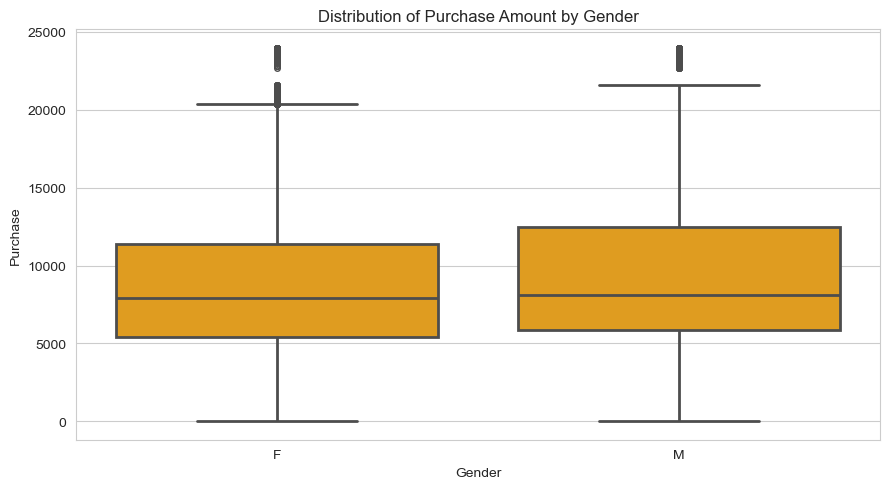

In [96]:
plt.figure(figsize=(9, 5))
ax = sns.boxplot(x=df['Gender'], y=df['Purchase'], 
                 color='orange',
                 linewidth=2,
                 fliersize=4)
plt.title("Distribution of Purchase Amount by Gender")
plt.tight_layout()
plt.show()

#### Interpretation:
While both genders exhibit high-value transactions, the overall spread of purchases appears slightly wider for male customers, whereas female customers demonstrate a comparatively tighter interquartile range.

The median purchase amount remains similar across both groups, indicating comparable central spending tendencies.

### 6.2 Marital Status vs Purchase

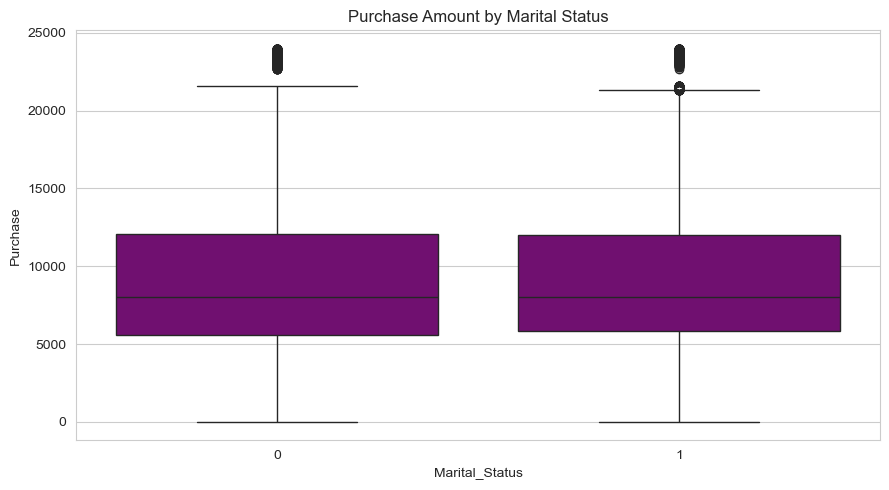

In [99]:
plt.figure(figsize= (9, 5))
sns.boxplot(data= df, x= 'Marital_Status', y= 'Purchase', color= 'Purple')
plt.title("Purchase Amount by Marital Status")
plt.tight_layout()
plt.show()

#### Interpretation:
The married group shows a slightly higher upper spread, indicating the presence of some higher-value transactions.

However, both groups exhibit similar median spending, suggesting comparable central purchasing behavior.

### 6.3 Age vs Purchase

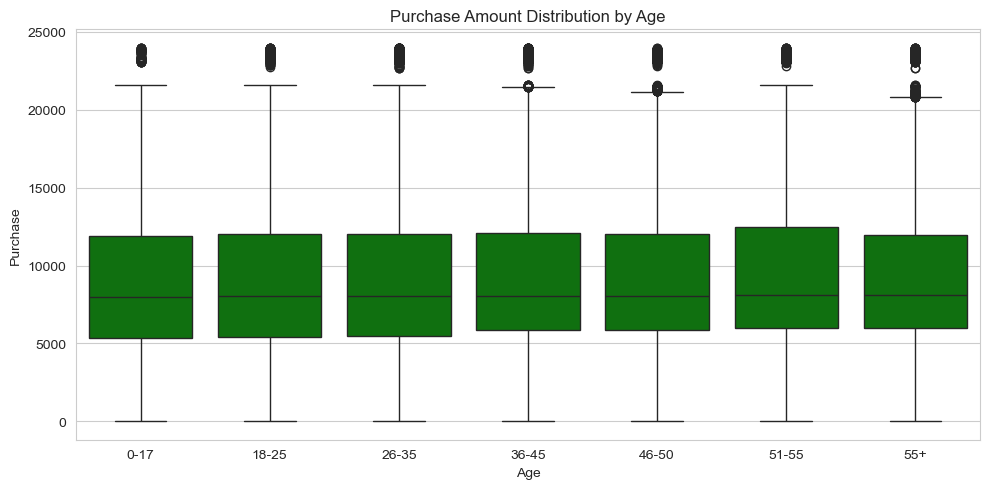

In [102]:
# Defining the correct age group order
age_order = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x= 'Age', y= 'Purchase', color= 'green', order= age_order)
plt.title("Purchase Amount Distribution by Age")
plt.tight_layout()
plt.show()

#### Interpretation:
These boxplots for all the 7 categories of group show almost identical distribution of purchases amounts. 

Age groups 36-45, 46-50 and 55+ show more number of high-value transactions in comparison to other remaining groups. 

Age groups 0-17, 18-25 and 26-35 show a relatively higher upper spread. 

All the age groups, despite having difference in data, shows a common median average among them.

### 6.4 Correlation Analysis

In [105]:
# Creating a copy of the dataset, instead of working directly on the dataset
corr_df = df.copy()

# Encode categorical variables temporarily
corr_df['Gender'] = corr_df['Gender'].map({'F': 0, 'M': 1})
corr_df['Marital_Status'] = corr_df['Marital_Status'].astype(int)
corr_df['Age_Code'] = corr_df['Age'].astype('category').cat.codes
corr_df['City_Code'] = corr_df['City_Category'].astype('category').cat.codes

# Select relevant columns
corr_cols = [
    'Purchase',
    'Gender',
    'Marital_Status',
    'Age_Code',
    'City_Code'
]

corr_matrix = corr_df[corr_cols].corr()
corr_matrix

,Purchase,Gender,Marital_Status,Age_Code,City_Code
Purchase,1.000000,0.060346,-0.000463,0.015839,0.061914
Gender,0.060346,1.000000,-0.011603,-0.004262,-0.004515
Marital_Status,-0.000463,-0.011603,1.000000,0.311738,0.039790
Age_Code,0.015839,-0.004262,0.311738,1.000000,0.123079
City_Code,0.061914,-0.004515,0.039790,0.123079,1.000000


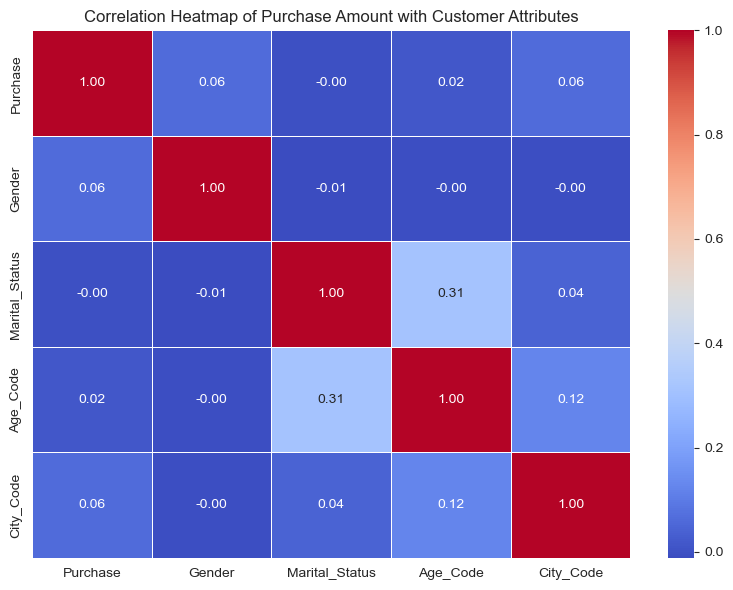

In [106]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Purchase Amount with Customer Attributes")
plt.tight_layout()
plt.show()

#### Interpretation:
The correlation heatmap shows that purchase amount has weak linear correlation with demographic attributes such as gender, marital status, age group, and city category.

This indicates that no single demographic variable strongly explains purchase behavior on its own, reinforcing the need to rely on distribution-based and confidence-interval–based analysis rather than simple correlation metrics.

These weak correlations further justify the use of sampling-based inference methods, as demographic variables alone do not capture the variability in individual purchase behavior.

## Section 7: CLT & Confidence Intervals

### 7.1 Central Limit Theorem

##### Step 1: Defining the population:

For this analysis:

Population of interest:
All purchase transactions made by the female customer population (assumed to be 50 million customers).

Reality:
We do not have data for all 50 million customers, instead we just have a sample of approximately 135K female purchase transactions from the dataset.

##### Step 2: Stating the problem CLT helps us solve:

The raw purchase distribution for female customers:

• Is right-skewed

• Contains outliers

• Is not normally distributed

So the question becomes:

How can we still make reliable statements about the average spending of all female customers?

This is exactly where CLT is used.

##### Step 3: CLT idea explained:

Central Limit Theorem states that, for sufficiently large sample sizes, the distribution of sample means tends to follow a normal distribution, regardless of the shape of the original population distribution.

In the context of this analysis, although individual purchase amounts made by female customers are skewed and irregular, the distribution of average purchase amounts computed from repeated random samples of female customers will approximate a normal distribution, provided the sample size is sufficiently large.

##### Step 4: What “sample means” means here:

-> We randomly select n female purchase transactions

-> We compute the average purchase amount

-> We repeat this process many times

-> Each repetition gives one sample mean

-> These sample means together form: **Distribution of sample means**

And this distribution is what CLT talks about — not the original purchase data.

##### Step 5: Why CLT is valid in THIS dataset:

Since the dataset contains a large number of independent purchase transactions with finite variance, the conditions required for the Central Limit Theorem are satisfied. Hence, CLT can be reasonably applied to analyze average purchase behavior of female customers.

##### Step 6: Why CLT is important for business:

Applying CLT allows Walmart to move away from noisy individual transaction data and focus on the average spending behavior, which is more stable, interpretable, and suitable for decision-making at a population level.

### 7.2 Sampling & Distribution of Sample Means

##### Step 1: Kind of sampling

In order to apply the Central Limit Theorem, multiple random samples are drawn from the female purchase transaction data. Each sample consists of a fixed number of purchase transactions selected randomly and independently.

##### Step 2: Why Sample size matters

To observe the effect of sample size on the distribution of sample means, different sample sizes are considered (for example, small, medium, and large samples). This helps in understanding how quickly the sampling distribution stabilizes as sample size increases.

##### Step 3: What exactly is computed for each sample

For each random sample, the mean purchase amount is computed. This process is repeated many times, and each repetition yields one sample mean.

##### Step 4: What is the “distribution of sample means”

The collection of all sample means obtained from repeated sampling forms the distribution of sample means.

According to the Central Limit Theorem, this distribution approaches a normal distribution as the sample size increases, even if the original purchase data is not normally distributed.

##### Step 5: Observation when sample size increases

As the sample size increases, the distribution of sample means becomes more concentrated around the population mean and exhibits reduced variability.

Smaller samples tend to produce more dispersed sample means, while larger samples produce tighter and more stable distributions.

##### Step 6: Why this matters before confidence intervals

Understanding the behavior of the sampling distribution of the mean is essential before constructing confidence intervals, as confidence intervals are directly derived from the variability observed in the distribution of sample means.

##### Note:
Figure X (Appendix) illustrates the sampling distribution of mean purchase amounts for female customers at different sample sizes. As the sample size increases, the distribution of sample means becomes more concentrated and increasingly normal in shape, consistent with the Central Limit Theorem. This reduction in variability explains the narrow confidence intervals observed for large samples.

As sample size increases, the sampling distribution becomes narrower, which directly translates into smaller standard errors and tighter confidence intervals for the mean.

### 7.3 Confidence Intervals (Female Customers)

##### Step 1: What a Confidence Interval means

A confidence interval provides a range of values within which the true population mean is expected to lie, with a specified level of confidence.

In this analysis, the confidence interval represents a plausible range for the average purchase amount of all female customers, based on the observed sample data.

##### Step 2: Why we need Confidence Intervals

While the sample mean gives a single-point estimate of average spending, it does not account for sampling variability. Confidence intervals address this uncertainty by providing a range rather than a single value.

##### Step 3: Confidence Levels (90%, 95%, 99%)

Different confidence levels such as 90%, 95%, and 99% are considered. A higher confidence level corresponds to a wider interval, indicating greater certainty but less precision.

##### Step 4: How CLT enables Confidence Intervals here

Since the distribution of sample means for female customers approximates a normal distribution due to the Central Limit Theorem, standard confidence interval methods for the mean can be applied.

##### Step 5: Interpreting a Confidence Interval

A 95% confidence interval does not imply that there is a 95% probability that the true mean lies within the interval. Instead, it means that if the sampling process were repeated many times, approximately 95% of the constructed intervals would contain the true population mean.

##### Step 6: Observing the effect of confidence level on interval width

It is observed that as the confidence level increases from 90% to 99%, the confidence interval becomes wider. This reflects a trade-off between certainty and precision.

##### Step 7: Business interpretation for female customers

For Walmart, confidence intervals provide a reliable range for expected average spending by female customers, helping decision-makers account for uncertainty while planning promotions, pricing strategies, and inventory allocation during peak sales events.

Note: The numeric confidence intervals used for interpretation are provided in the Appendix.

### 7.4: Confidence Intervals (Male Customers)

##### Step 1: Defining the population

Population of interest:
All purchase transactions made by the male customer population (assumed to be 50 million customers) during the Black Friday sale at Walmart.

The dataset contains a large sample of male purchase transactions approximately 415K, which is used as a representative sample for inference at the population level.

##### Step 2: Why CLT applies equally to male customers

Similar to female customers, the raw distribution of purchase amounts for male customers is skewed and contains outliers. However, due to the large number of independent transactions and finite variance, the Central Limit Theorem is applicable.

##### Step 3: Sampling logic

Multiple random samples of fixed size are drawn from the male purchase transactions. For each sample, the mean purchase amount is calculated. Repeating this process multiple times results in a distribution of sample means.

##### Step 4: Distribution of sample means

According to the Central Limit Theorem, the distribution of sample means for male customers approaches a normal distribution as the sample size increases, regardless of the non-normality of the original purchase data.

##### Step 5: Constructing confidence intervals

Using the distribution of sample means, confidence intervals are constructed for the average purchase amount of male customers at different confidence levels such as 90%, 95%, and 99%.

##### Step 6: Interpreting confidence intervals

A confidence interval represents a range of plausible values for the true population mean purchase amount of male customers. A higher confidence level results in a wider interval, reflecting greater certainty but lower precision.

##### Step 7: Business interpretation (male customers)

For Walmart, the confidence interval for male customers provides a statistically reliable range of expected average spending, helping quantify uncertainty in male purchasing behavior during major sales events.

Note: The numeric confidence intervals used for interpretation are provided in the Appendix.

### 7.5: Comparison of Confidence Intervals:= Female vs Male Customers

##### Step 1: What is being compared
In this section, the confidence intervals for the average purchase amount of female and male customers are compared to assess whether a statistically meaningful difference exists in their spending behavior during the Black Friday sale.

##### Step 2: Overlap vs Non-Overlap
Based on the numeric confidence intervals reported in the Appendix, the confidence intervals for the average purchase amount of male and female customers do not overlap across the confidence levels considered. This provides statistical evidence of a difference in average spending behavior between the two groups.

##### Step 3: Observation from the Analysis
The non-overlapping confidence intervals indicate that the average purchase amount per transaction is higher for male customers than for female customers at the population level.

##### Step 4: Business Question – Are women spending more money per transaction than men?
The confidence interval analysis indicates that male customers spend more per transaction on average than female customers during the Black Friday sale. However, this result represents an average population-level effect and does not imply that individual male customers always spend more than individual female customers.

##### Step 5: Business Interpretation
From a business perspective, while the difference in average spending is statistically significant, the magnitude of the difference is relatively modest. Walmart should therefore avoid simplistic gender-based targeting strategies and instead incorporate additional behavioral and product-level signals when designing promotional or pricing strategies.

##### Step 6: Why Confidence Intervals Are Better Than Just Comparing Means
Confidence intervals provide a more reliable and uncertainty-aware comparison than point estimates alone, as they account for sampling variability and help distinguish between statistically meaningful differences and random fluctuations in sample means.

##### Note:
The numeric confidence intervals for female and male customers at 90%, 95%, and 99% confidence levels are provided in the Appendix and form the basis of the conclusions above.

### 7.6: CLT & Confidence Intervals:= Married vs Unmarried Customers

##### Step 1: Defining populations

Population of interest:
All purchase transactions made by married and unmarried customers during the Black Friday sale at Walmart.

The dataset contains a large number of purchase transactions for both married and unmarried customers, which are treated as representative samples for population-level inference.

##### Step 2: Applicability of CLT

Similar to gender-based analysis, the purchase amount distributions for both married and unmarried customers are skewed and contain outliers. However, due to the large sample sizes and independent transactions, the Central Limit Theorem is applicable for analyzing average purchase behavior.

##### Step 3: Sampling & distribution of sample means

Multiple random samples of fixed size are drawn independently from the married and unmarried customer groups. For each sample, the mean purchase amount is calculated. Repeating this process produces distributions of sample means for both groups.

##### Step 4: Confidence interval construction

Using the sampling distributions of the mean, confidence intervals for the average purchase amount of married and unmarried customers are constructed at different confidence levels such as 90%, 95%, and 99%.

##### Step 5: Comparison of confidence intervals

Upon comparing the confidence intervals of married and unmarried customers, it is observed that the intervals show substantial overlap across the confidence levels considered. This suggests that the average purchase amounts of married and unmarried customers are statistically comparable at the population level.

##### Step 6: Business interpretation

The overlapping confidence intervals indicate that marital status alone may not be a strong differentiator of average spending behavior during Black Friday. Walmart may therefore benefit more from combining marital status with other attributes such as age or product category when designing targeted offers.

##### Note:
The numeric confidence intervals for married and unmarried customers (reported in the Appendix) show substantial overlap across all confidence levels, supporting the conclusion that marital status alone does not meaningfully differentiate average spending behavior.

### 7.7: CLT & Confidence Intervals:= Purchase Behavior Across Age Groups

##### Step 1: Defining age-based populations

Population of interest:
All purchase transactions made by customers across different age groups during the Black Friday sale at Walmart.

The analysis considers age categories representing different life stages: 0–17, 18–25, 26–35, 36–45, 46–50, 51–55, and 55+ years.

##### Step 2: CLT applicability across age groups

Although purchase distributions within individual age groups are skewed and vary in spread, each age group contains a sufficiently large number of transactions. Therefore, the Central Limit Theorem is applicable for estimating the average purchase amount within each age category.

##### Step 3: Sampling & confidence intervals by age group

For each age group, multiple random samples are drawn and sample means are computed. Based on the sampling distributions of the mean, confidence intervals are constructed for the average purchase amount at different confidence levels.

##### Step 4: Comparison of confidence intervals across age groups

When comparing confidence intervals across age groups, it is observed that many of the intervals overlap significantly, indicating broadly similar average spending behavior across age categories. However, certain older age groups show slightly higher upper bounds, suggesting the presence of higher-value transactions.

##### Step 5: Business interpretation

From a business perspective, while average spending across age groups appears largely comparable, subtle differences at the upper end of the distribution may indicate opportunities for age-specific premium offerings. Walmart can leverage this insight by customizing product bundles or promotions based on life-stage preferences rather than relying solely on age as a spending predictor.

##### Note:
The numeric confidence intervals for average purchase amounts across age groups (reported in the Appendix) show substantial overlap, indicating broadly similar average spending behavior across life stages, with slightly higher upper bounds for older age groups.

## Section 8: Final Insights

#### 8.1 Overall Customer Purchase Behavior

• The purchase amount per transaction during the Black Friday sale shows high variability and right-skewness, which is typical of large-scale retail transactions.

• A small proportion of high-value purchases contributes disproportionately to overall revenue, while the majority of transactions cluster around the median spending range.

• Due to this skewed nature of raw transaction data, population-level inference based on averages requires the use of sampling-based methods, justified through the Central Limit Theorem.

#### 8.2 Gender-Based Insights (Female vs Male)

• Confidence interval analysis shows that the average purchase amount per transaction for male customers is statistically higher than that of female customers during the Black Friday sale.

• The confidence intervals for male and female customers do not overlap across the considered confidence levels, providing statistical evidence of a difference in mean spending at the population level.

• However, the magnitude of this difference is relatively modest, and the distributions of individual purchase amounts across genders still exhibit substantial overlap.

• Therefore, while a statistically significant difference exists in average spending, it should be interpreted cautiously and not used as a standalone basis for aggressive gender-based targeting strategies.

#### 8.3 Marital Status Insights (Married vs Unmarried)

• Similar to gender-based analysis, the confidence intervals for average purchase amounts of married and unmarried customers show substantial overlap.

• This suggests that marital status alone is not a strong differentiator of average spending behavior during the sale period.

• Any minor differences observed at the sample level do not translate into statistically meaningful distinctions at the population level.

#### 8.4 Age-Based Insights

• Across different age groups, the average purchase amounts appear largely consistent, with confidence intervals overlapping for most age categories.

• However, certain older age groups display slightly higher upper bounds, suggesting the presence of higher-value transactions rather than a uniformly higher average spend.

• These observations indicate that while age alone does not dramatically change average spending, life-stage–related preferences may influence premium purchasing behavior.

#### 8.5 Statistical Inference & Reliability

• Despite the non-normal and skewed nature of individual purchase transactions, the Central Limit Theorem enables reliable estimation of population-level average spending through the distribution of sample means.

• Confidence intervals provide a more robust and uncertainty-aware framework compared to simple point estimates, allowing Walmart to make informed decisions without overinterpreting small differences.

• The consistent overlap of confidence intervals across multiple customer segments reinforces the importance of data-driven caution when designing demographic-based strategies.

#### 8.6 Key Takeaway for Business

• The analysis indicates that average spending behavior is broadly similar across gender, marital status, and age groups during the Black Friday sale.

• Differences in spending patterns are subtle rather than drastic, and relying solely on demographic segmentation may not yield significant improvements in decision-making.

• A more effective strategy would involve combining demographic attributes with product-level and behavioral insights to identify high-value opportunities.

## Section 9: Recommendations

#### 9.1 Rethink Gender-Based Targeting

• Since the average spending per transaction is statistically similar across male and female customers, Walmart should avoid heavy gender-based pricing or promotional strategies during major sales events like Black Friday.

• Gender-neutral offers and broad promotions are likely to be more efficient and inclusive, reducing unnecessary segmentation complexity.

#### 9.2 Use Marital Status as a Supporting Signal, Not a Primary Driver

• Marital status alone does not significantly differentiate average customer spending.

• Walmart should treat marital status as a secondary attribute, combining it with other factors such as shopping frequency, product categories, or total basket value for more meaningful targeting.

#### 9.3 Focus on Life-Stage Preferences Rather Than Age Alone

While average spending across age groups is broadly similar, older age groups show signs of higher-value purchases. Walmart can leverage this by:

• Curating premium product bundles for mature customer segments.

• Offering value-based upselling rather than blanket discounts for age-specific campaigns.

#### 9.4 Shift Strategy from Demographics to Behavior

Demographic factors such as gender, age, and marital status show limited standalone impact on average spending.

Walmart should prioritize behavioral segmentation, such as:

• Repeat purchases

• High basket value customers

• Product category preferences

These signals are more likely to drive measurable revenue impact.

#### 9.5 Plan with Ranges, Not Single Numbers

Confidence intervals provide a realistic range of expected average spending rather than a single estimate.

Walmart should incorporate these ranges into forecasting, inventory planning, and promotional budgeting to better handle uncertainty during peak sales periods.

#### 9.6 Avoid Over-Interpreting Small Differences

Minor differences in average spending observed in sample data may not represent true population-level differences.

Business decisions should be guided by statistically meaningful patterns, reducing the risk of overfitting marketing strategies to short-term noise.

#### 9.7 Data-Driven Culture & Continuous Monitoring

Walmart should continue monitoring customer spending behavior across major sales events using:

• Large samples

• Confidence intervals

• Periodic validation of assumptions

This ensures strategies remain adaptive, evidence-based, and reliable over time.

#### Final Business Message

*The analysis suggests that while customer spending behavior varies at an individual level, average spending across major demographic groups remains broadly similar. Walmart can maximize impact by focusing less on demographic labels and more on customer behavior, product preferences, and data-driven uncertainty-aware planning.*

### Appendix: Confidence Interval Calculations

#### Gender-wise Confidence Intervals

In [123]:
from scipy.stats import norm

def compute_ci(data, confidence_levels=[0.90, 0.95, 0.99]):
    mean = data.mean()
    std = data.std(ddof=1)
    n = len(data)
    
    results = []
    for cl in confidence_levels:
        z = norm.ppf((1 + cl) / 2)
        margin = z * (std / np.sqrt(n))
        lower = mean - margin
        upper = mean + margin
        results.append((cl, lower, upper))
    
    return mean, results

# Separate female and male purchases
female_purchase = df[df['Gender'] == 'F']['Purchase']
male_purchase = df[df['Gender'] == 'M']['Purchase']

female_mean, female_cis = compute_ci(female_purchase)
male_mean, male_cis = compute_ci(male_purchase)

female_mean, female_cis, male_mean, male_cis

(8734.565765155476,
 [(0.9, 8713.287834648021, 8755.84369566293),
  (0.95, 8709.21154714068, 8759.919983170272),
  (0.99, 8701.24467443839, 8767.88685587256)],
 9437.526040472265,
 [(0.9, 9424.512497305488, 9450.539583639042),
  (0.95, 9422.01944736257, 9453.032633581959),
  (0.99, 9417.146922669479, 9457.90515827505)])

In [124]:
ci_table = []

for cl, low, high in female_cis:
    ci_table.append(['Female', cl, female_mean, low, high])

for cl, low, high in male_cis:
    ci_table.append(['Male', cl, male_mean, low, high])

ci_df = pd.DataFrame(
    ci_table,
    columns=['Gender', 'Confidence_Level', 'Mean_Purchase', 'CI_Lower', 'CI_Upper']
)

ci_df

,Gender,Confidence_Level,Mean_Purchase,CI_Lower,CI_Upper
0,Female,0.90,8734.565765,8713.287835,8755.843696
1,Female,0.95,8734.565765,8709.211547,8759.919983
2,Female,0.99,8734.565765,8701.244674,8767.886856
3,Male,0.90,9437.526040,9424.512497,9450.539584
4,Male,0.95,9437.526040,9422.019447,9453.032634
5,Male,0.99,9437.526040,9417.146923,9457.905158


#### Sampling Distribution (CLT Demonstration)

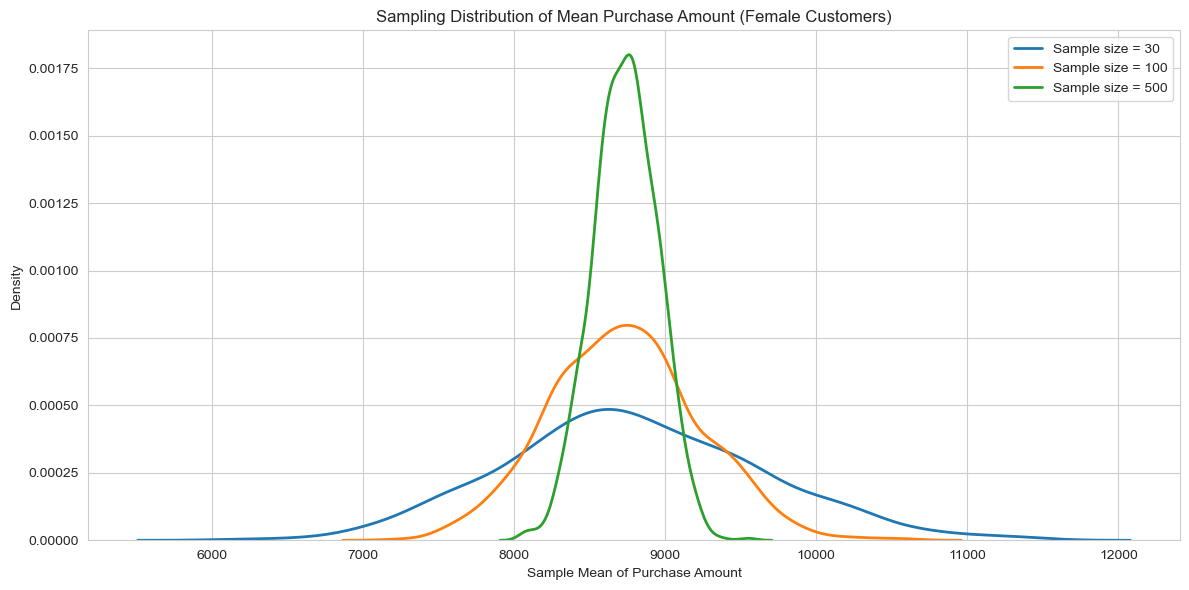

In [126]:
# Helper function to generate sample means
def sample_means(data, sample_size, n_samples=1000):
    means = []
    for _ in range(n_samples):
        sample = np.random.choice(data, size=sample_size, replace=True)
        means.append(sample.mean())
    return means

# Generating sample means for different sample sizes for Female customers
female_data = df[df['Gender'] == 'F']['Purchase']

means_30 = sample_means(female_data, sample_size=30)
means_100 = sample_means(female_data, sample_size=100)
means_500 = sample_means(female_data, sample_size=500)

#Plotting the sampling distributions
plt.figure(figsize=(12, 6))

sns.kdeplot(means_30, label='Sample size = 30', linewidth=2)
sns.kdeplot(means_100, label='Sample size = 100', linewidth=2)
sns.kdeplot(means_500, label='Sample size = 500', linewidth=2)

plt.title("Sampling Distribution of Mean Purchase Amount (Female Customers)")
plt.xlabel("Sample Mean of Purchase Amount")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

#### Confidence Interval: Married vs Unmarried Customers

In [128]:
married_purchase = df[df['Marital_Status'] == '1']['Purchase']
unmarried_purchase = df[df['Marital_Status'] == '0']['Purchase']

married_mean, married_cis = compute_ci(married_purchase)
unmarried_mean, unmarried_cis = compute_ci(unmarried_purchase)

# Build table
ci_marital = []

for cl, low, high in married_cis:
    ci_marital.append(['Married', cl, married_mean, low, high])

for cl, low, high in unmarried_cis:
    ci_marital.append(['Unmarried', cl, unmarried_mean, low, high])

ci_marital_df = pd.DataFrame(
    ci_marital,
    columns=['Marital_Status', 'Confidence_Level', 'Mean_Purchase', 'CI_Lower', 'CI_Upper']
)

ci_marital_df

,Marital_Status,Confidence_Level,Mean_Purchase,CI_Lower,CI_Upper
0,Married,0.90,9261.174574,9243.790714,9278.558434
1,Married,0.95,9261.174574,9240.460427,9281.888721
2,Married,0.99,9261.174574,9233.951570,9288.397578
3,Unmarried,0.90,9265.907619,9251.396386,9280.418852
4,Unmarried,0.95,9265.907619,9248.616418,9283.198820
5,Unmarried,0.99,9265.907619,9243.183129,9288.632109


#### Confidence Interval: Age Groups

In [130]:
age_groups = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

ci_age = []

for age in age_groups:
    age_data = df[df['Age'] == age]['Purchase']
    
    mean, cis = compute_ci(age_data)
    
    for cl, low, high in cis:
        ci_age.append([age, cl, mean, low, high])

ci_age_df = pd.DataFrame(
    ci_age,
    columns=['Age_Group', 'Confidence_Level', 'Mean_Purchase', 'CI_Lower', 'CI_Upper']
)

ci_age_df

,Age_Group,Confidence_Level,Mean_Purchase,CI_Lower,CI_Upper
0,0-17,0.90,8933.464640,8865.053695,9001.875586
1,0-17,0.95,8933.464640,8851.947971,9014.981310
2,0-17,0.99,8933.464640,8826.333576,9040.595704
3,18-25,0.90,9169.663606,9143.433032,9195.894181
4,18-25,0.95,9169.663606,9138.407949,9200.919264
5,18-25,0.99,9169.663606,9128.586709,9210.740503
6,26-35,0.90,9252.690633,9235.103001,9270.278265
7,26-35,0.95,9252.690633,9231.733676,9273.647589
8,26-35,0.99,9252.690633,9225.148523,9280.232742
9,36-45,0.90,9331.350695,9306.441376,9356.260014


---- >>>> ***Thank You*** <<<< ----